# Analyze the outputs of K-fold cross validation for tuning the beta parameter

First we need to load some basic datasets. We may use them later

/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data path: /home/donglaiyang/Documents/Georgia-Tech/Research/thermal-model/Amundsen-thermal-output-Yang/thermal-training-data/Thwaites-PIG/training/gridded/
Parameter path: /home/donglaiyang/Documents/Georgia-Tech/Research/thermal-model/data/post-processing-parameters.csv
Output path: /data-archive/ASE-inference/train-validate-test/
Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 937)
Shape of Ns_standardized_train: (256, 256, 1, 937)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


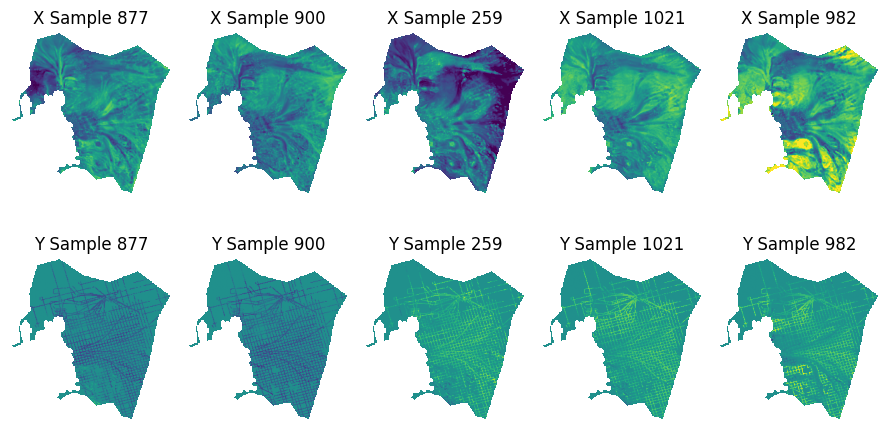

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model
from src.ice import compute_pmp

%load_ext autoreload
%autoreload 2

data_path       = os.getenv('RAW_DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
output_path     = os.getenv('INFERENCE_READY_DATA_PATH')
print("Data path:", data_path)
print("Parameter path:", param_path)
print("Output path:", output_path)
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized_train = np.load(output_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(output_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(output_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(output_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(output_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(output_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# compute pmp
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)


# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)

# -----------------------------------------------------------------------------------------------------------------------------
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

# load pmp
md.pmp = pmp

PCA model saved to self.pca_x and self.pca_y.
Shape of XY_train: (937, 65)
Shape of XY_validation: (0, 65)
Shape of XY_test: (105, 65)
GMM training completed in 1.23 seconds.


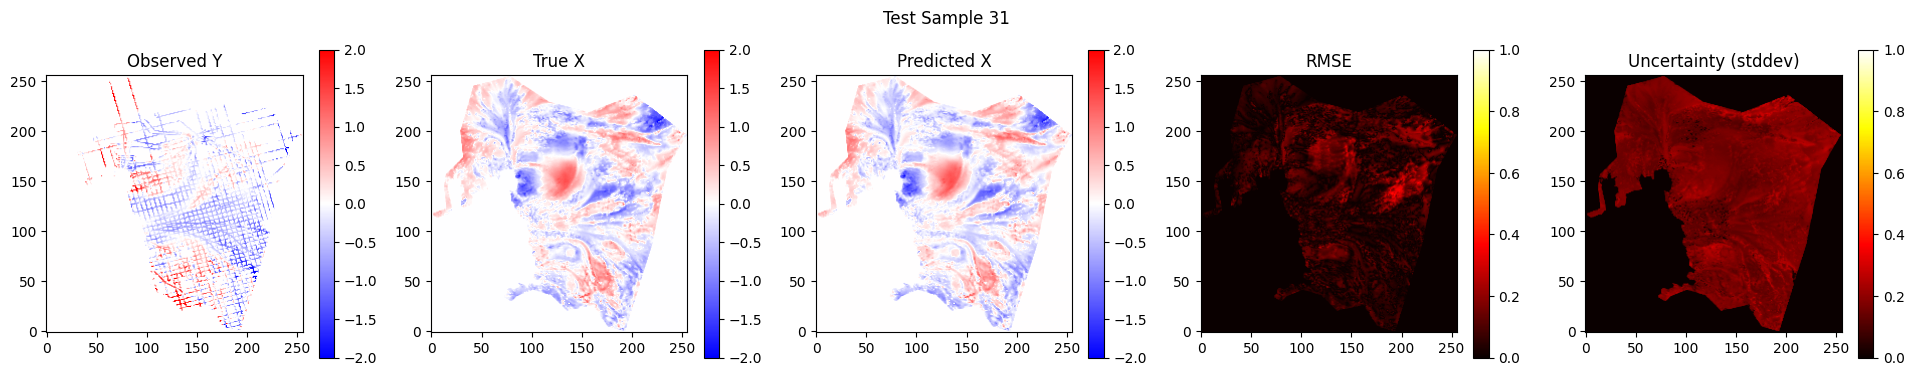

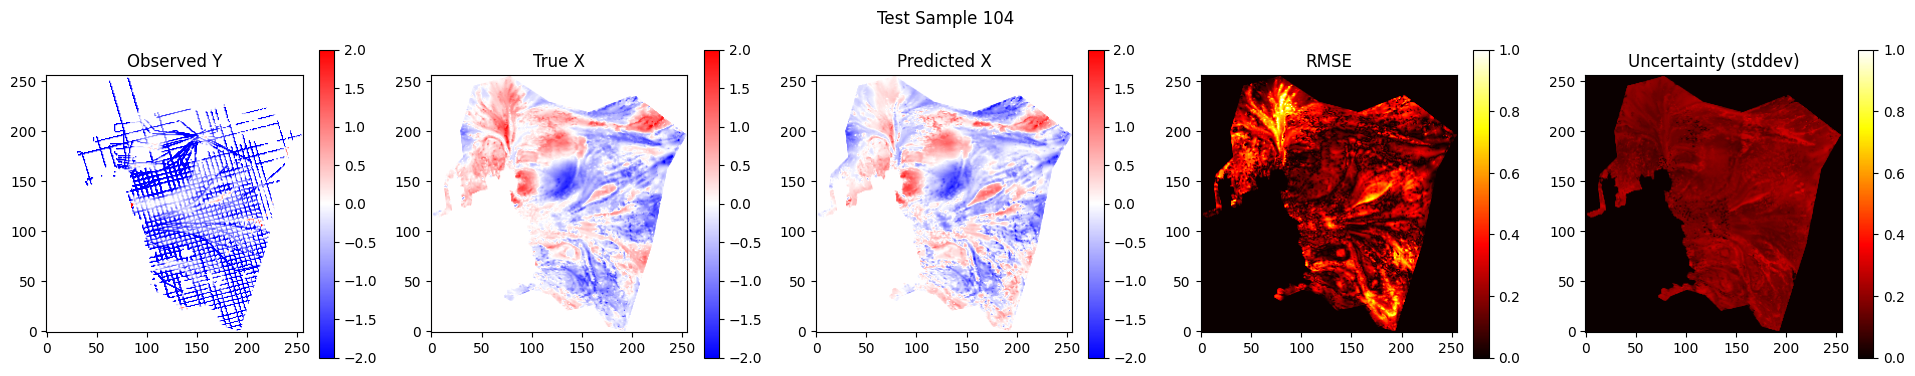

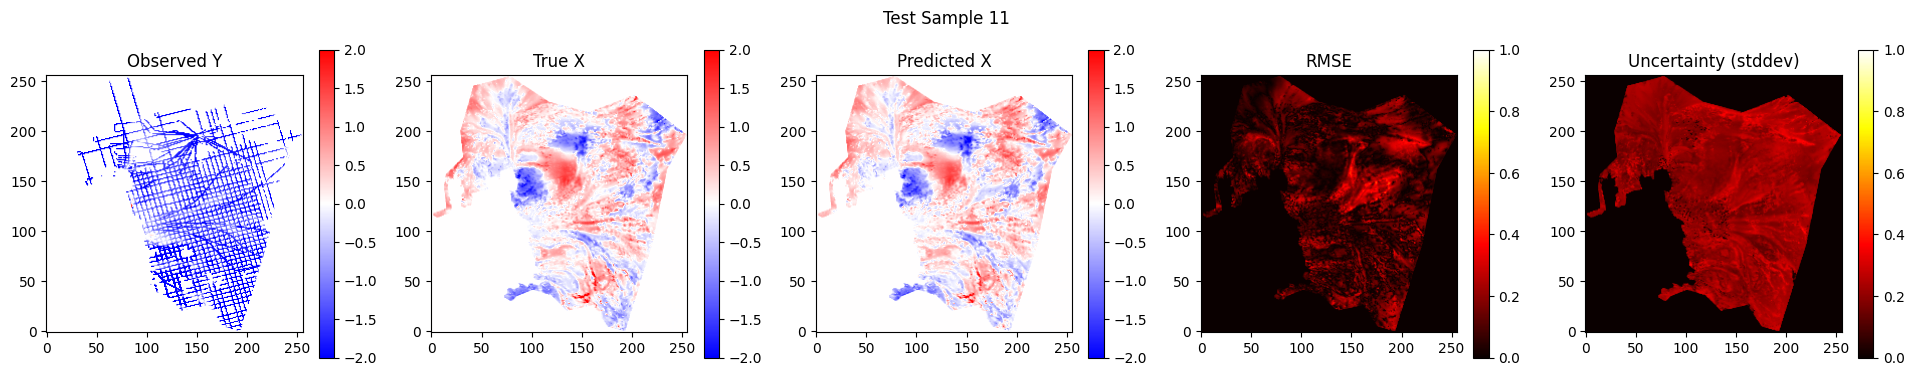

In [2]:
from src.validation import bayesian_information_criterion

# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=50, n_component_y=15)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train, Y_train=Ns_standardized_train,
                   X_validation=Eb_standardized_valid, Y_validation=Ns_standardized_valid,
                   X_test=Eb_standardized_test, Y_test=Ns_standardized_test)


# based on the BIC sweep plot
n_optimal = 20
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples_pca(n_samples=3)

shape of Y_obs: (256, 256)


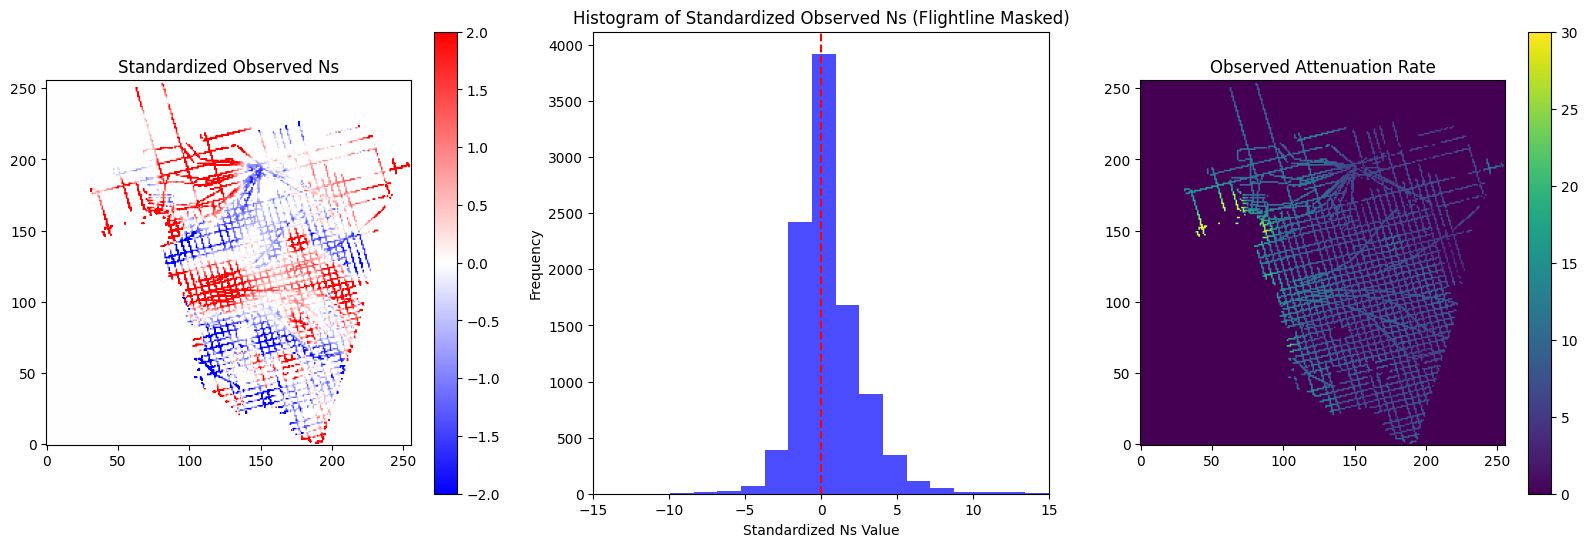

Density at init: [5.57588967e-07]
 Likelihood: 96876.245, Prior: 14.400
 Likelihood: 307831.385, Prior: 158.661
 Likelihood: 89161.636, Prior: 18.003
 Likelihood: 88025.000, Prior: 20.088
 Likelihood: 82893.794, Prior: 57.065
 Likelihood: 80955.780, Prior: 91.314
 Likelihood: 79103.501, Prior: 150.630
 Likelihood: 78142.149, Prior: 143.211
 Likelihood: 77616.072, Prior: 131.636
 Likelihood: 77486.225, Prior: 126.938
 Likelihood: 77265.655, Prior: 121.330
 Likelihood: 77203.666, Prior: 122.461
 Likelihood: 77182.393, Prior: 123.011
 Likelihood: 77172.668, Prior: 124.403
 Likelihood: 77168.438, Prior: 125.264
 Likelihood: 77167.500, Prior: 125.011
 Likelihood: 77166.332, Prior: 124.668
 Likelihood: 77163.985, Prior: 124.071
 Likelihood: 77160.251, Prior: 123.290
 Likelihood: 77158.053, Prior: 122.855
 Likelihood: 77156.512, Prior: 122.972
 Likelihood: 77156.212, Prior: 123.065
 Likelihood: 77156.166, Prior: 123.094
 Likelihood: 77156.167, Prior: 123.092
 Likelihood: 77156.179, Prior: 123

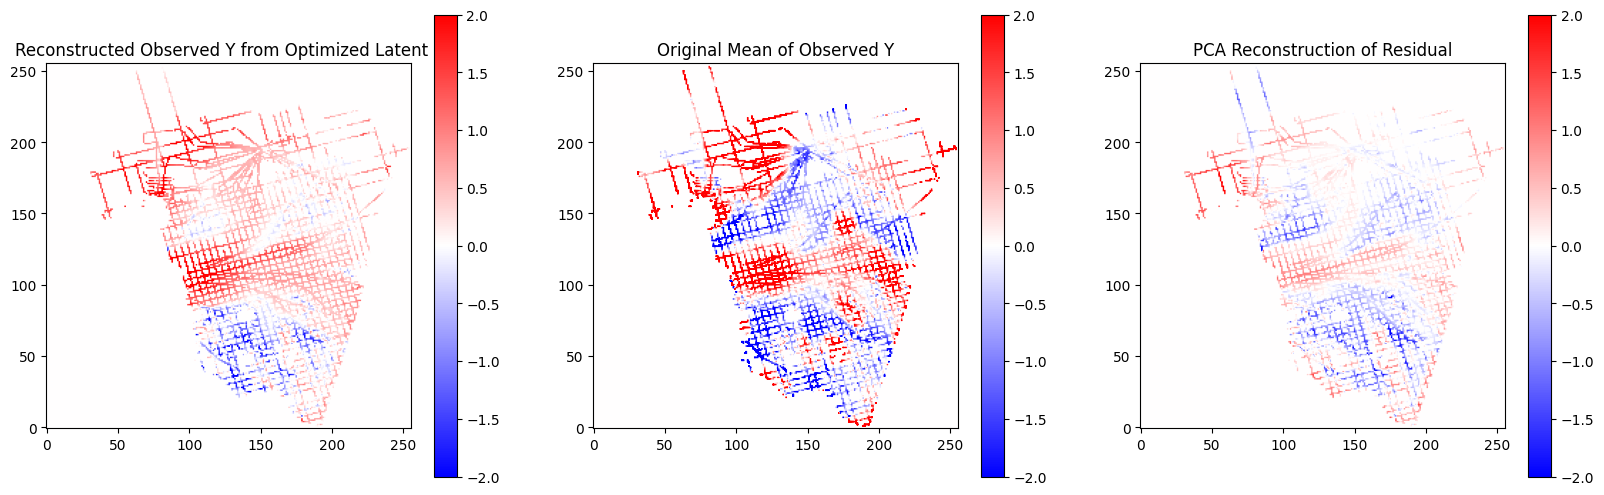

first 5x5 block of cov_obs_latent:
[[ 3.49958769e+04  4.65348521e-04  9.63090889e-05 -7.87918820e-04]
 [ 4.65348521e-04  3.04983835e+03  5.76216042e-03 -4.71410818e-02]
 [ 9.63090889e-05  5.76216042e-03  1.40931144e+03 -9.75637491e-03]
 [-7.87918820e-04 -4.71410818e-02 -9.75637491e-03  4.21227341e+02]]
min eigenvalue: 41.48040193825571
conditioned indices are:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


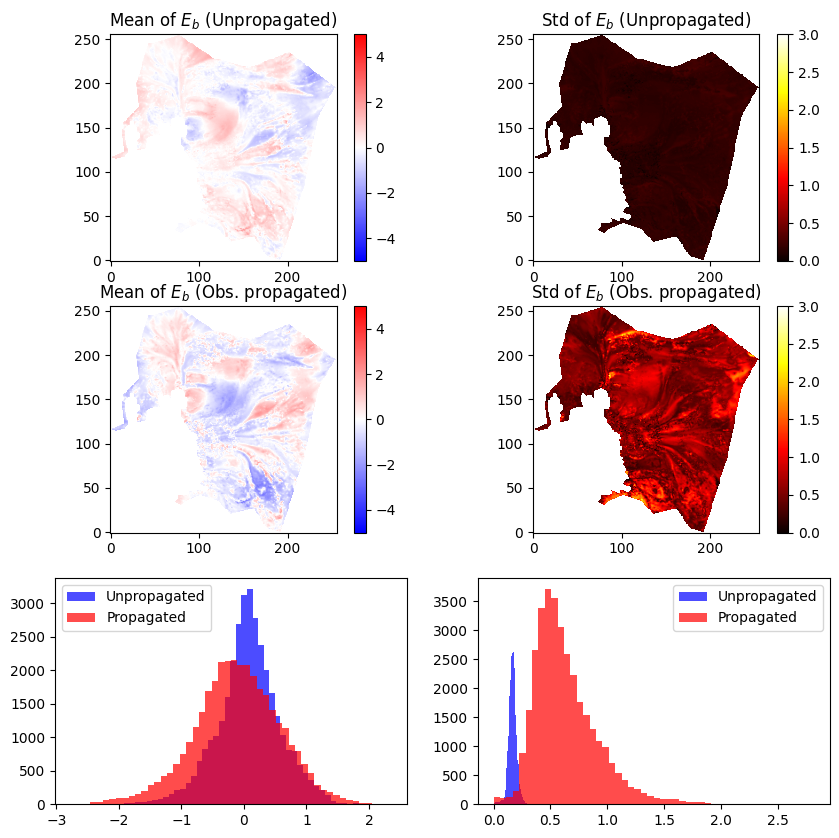

In [4]:
md.load_obs_data(atten_rate_avg)

# the beta_prior comes from the L-curve plot
beta_prior = 0.00001
lambda1, lambda2 = 1,5
md.derive_prior(beta=beta_prior, lambda1=lambda1, lambda2=lambda2)

# K-Fold Cross Validation with thinning

For each k-fold split data set, we apply varying degrees of thinning (i.e. random subsampling) for the MAP estimation, and for each thinning level we sweep through several choices of beta (the temperature scale factor in the likelihood function). 

In [5]:
from src.validation import split_evidence
from src.optimization import loglikelihoods_sum
import torch
import contextlib
import copy
beta_w = 0.01
beta_posterior_list = [0.5, 1, 2, 3, 4, 5]
thinning_levels = [0.1, 0.2, 0.3, 0.5] # 10%, 20%, 30%, 50% thinning
cv_data_folder = os.getenv('INFERENCE_READY_DATA_PATH')

cv_fold_area_strpattern = "cv_fold_{}_areas.npz"
cv_fold_mask_strpattern = "cv_fold_{}_masks.npz"

# determine the total number of folds by checking the files in the cv_data_folder
cv_fold_area_files = [f for f in os.listdir(cv_data_folder) if f.startswith("cv_fold_") and f.endswith("_areas.npz")]
cv_fold_mask_files = [f for f in os.listdir(cv_data_folder) if f.startswith("cv_fold_") and f.endswith("_masks.npz")]
num_folds = len(cv_fold_area_files)
print("Number of folds detected:", num_folds)

# load one as an xample
data_area_example = np.load(os.path.join(cv_data_folder, cv_fold_area_strpattern.format(0)))
data_mask_example = np.load(os.path.join(cv_data_folder, cv_fold_mask_strpattern.format(0)))
# print the keys of the loaded data
print("Keys in area example:", data_area_example.keys())
print("Keys in mask example:", data_mask_example.keys())

Number of folds detected: 10
Keys in area example: KeysView(NpzFile '/data-archive/ASE-inference/train-validate-test/cv_fold_0_areas.npz' with keys: fold, val_thawed_area, val_frozen_area, train_thawed_area, train_frozen_area)
Keys in mask example: KeysView(NpzFile '/data-archive/ASE-inference/train-validate-test/cv_fold_0_masks.npz' with keys: fold, val_thawed, val_frozen, train_thawed, train_frozen)


In [70]:
# create xarray data frame to record ll with fold number, thinning level, and beta_posterior as coordinates
Tb_MAP_betas = xr.DataArray(
    data=np.nan,
    dims=["fold", "thinning", "beta_posterior", "grid_points"],
    coords={
        "fold": np.arange(num_folds),
        "thinning": thinning_levels,
        "beta_posterior": beta_posterior_list,
        "grid_points": np.arange(md.nx * md.ny)
    }
)
ll_betas = xr.DataArray(
    data=np.nan,
    dims=["fold", "thinning", "beta_posterior"],
    coords={
        "fold": np.arange(num_folds),
        "thinning": thinning_levels,
        "beta_posterior": beta_posterior_list
    }
)
hessian_inv_diag_betas = xr.DataArray(
    data=np.nan,
    dims=["fold", "thinning", "beta_posterior", "grid_points"],
    coords={
        "fold": np.arange(num_folds),
        "thinning": thinning_levels,
        "beta_posterior": beta_posterior_list,
        "grid_points": np.arange(md.ndim_reduced_x)
    }
)

error_collect = []

# suppress output 
np.random.seed(42)  # for reproducibility
for fold in range(num_folds):
# for fold in range(2):
    # load the areas and masks for this fold
    data_area = np.load(os.path.join(cv_data_folder, cv_fold_area_strpattern.format(fold)))
    data_mask = np.load(os.path.join(cv_data_folder, cv_fold_mask_strpattern.format(fold)))

    # extract the training and test areas and masks
    fold_num = data_mask['fold']
    train_thawed_mask = data_mask['train_thawed'].ravel()
    train_frozen_mask = data_mask['train_frozen'].ravel()
    val_thawed_mask   = data_mask['val_thawed'].ravel()
    val_frozen_mask   = data_mask['val_frozen'].ravel()

    train_thawed_frac = data_area['train_thawed_area'].ravel()  
    train_frozen_frac = data_area['train_frozen_area'].ravel()
    val_thawed_frac   = data_area['val_thawed_area'].ravel()
    val_frozen_frac   = data_area['val_frozen_area'].ravel()

    for thinning in thinning_levels:
        # randomly thin the training data based on the thinning level
        train_thawed_mask_thinned = train_thawed_mask.copy()
        train_frozen_mask_thinned = train_frozen_mask.copy()
        train_thawed_frac_thinned = train_thawed_frac.copy()
        train_frozen_frac_thinned = train_frozen_frac.copy()

        # randomly set a fraction of the training masks to False based on the thinning level
        train_thawed_indices = np.where(train_thawed_mask)[0]
        train_frozen_indices = np.where(train_frozen_mask)[0]
        num_thawed_to_remove = int(thinning * len(train_thawed_indices))
        num_frozen_to_remove = int(thinning * len(train_frozen_indices))
        thinned_thawed_indices = np.random.choice(train_thawed_indices, size=num_thawed_to_remove, replace=False)
        thinned_frozen_indices = np.random.choice(train_frozen_indices, size=num_frozen_to_remove, replace=False)
        train_thawed_mask_thinned[thinned_thawed_indices] = False
        train_frozen_mask_thinned[thinned_frozen_indices] = False
        train_thawed_frac_thinned[thinned_thawed_indices] = 0.0
        train_frozen_frac_thinned[thinned_frozen_indices] = 0.0
        # consistency check: report total number of true in both masks, and total area in both fractions
        print(f"Fold {fold}, Thinning {thinning}:")
        print(f"  Original thawed mask: {np.sum(train_thawed_mask)} true, Original frozen mask: {np.sum(train_frozen_mask)} true")
        print(f"  Thinned thawed mask: {np.sum(train_thawed_mask_thinned)} true, Thinned frozen mask: {np.sum(train_frozen_mask_thinned)} true")
        print(f"  Original thawed area: {np.sum(train_thawed_frac):.4f}, Original frozen area: {np.sum(train_frozen_frac):.4f}")
        print(f"  Thinned thawed area: {np.sum(train_thawed_frac_thinned):.4f}, Thinned frozen area: {np.sum(train_frozen_frac_thinned):.4f}")

        for beta_posterior in beta_posterior_list:
            md_copy = copy.deepcopy(md)  # deepcopy, not copy.copy
            print(f"...processing beta_posterior: {beta_posterior}, fold number {fold}, thinning level {thinning}")
            Tb_MAP_subsets = []
            ll_subsets = []

            # ── Fit on training set ───────────────────────────────────────
            try:
                n_iter = 20
                lr     = 0.02

                with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f):
                    md_copy.load_evidence(train_thawed_mask_thinned, train_thawed_frac_thinned,
                                            train_frozen_mask_thinned, train_frozen_frac_thinned,
                                            pmp, show_plot=False)
                    md_copy.compute_MAP(beta=beta_posterior, beta_w = beta_w, n_iter=n_iter, lr=lr, show_plot=False)

                # md_copy.load_evidence(train_thawed_mask_thinned, train_thawed_frac_thinned,
                #                         train_frozen_mask_thinned, train_frozen_frac_thinned,
                #                         pmp, show_plot=False)
                # md_copy.compute_MAP(beta=beta_posterior, beta_w = beta_w, n_iter=n_iter, lr=lr, show_plot=True)

                # ── Evaluate on held-out test fold ────────────────────────────
                Tb_MAP_subsets.append(md_copy.Tb_MAP.copy())
                Tb_flat = md_copy.Tb_MAP.copy().flatten()
                Eb_flat = md_copy.Eb_MAP.copy().flatten()
                Tb_flat[np.isnan(Tb_flat)] = 0.0
                Eb_flat[np.isnan(Eb_flat)] = 0.0

                with torch.no_grad():
                    ll = loglikelihoods_sum(beta_posterior,
                                            beta_w,
                                            torch.from_numpy(Tb_flat),
                                            torch.from_numpy(Eb_flat),
                                            torch.from_numpy(pmp),
                                            torch.from_numpy(val_thawed_frac), 
                                            torch.from_numpy(val_frozen_frac)) 
                ll_subsets.append(ll)

                # get the diagonal element of the inverse hessian
                hessian = md_copy.hessian_MAP
                hessian_inv = pinvh(-hessian)
                hessian_inv_diag = np.diag(hessian_inv)

                # save results to xarray
                Tb_MAP_betas.loc[fold, thinning, beta_posterior, :] = Tb_MAP_subsets[0].ravel()
                ll_betas.loc[fold, thinning, beta_posterior]        = ll_subsets[0]
                hessian_inv_diag_betas.loc[fold, thinning, beta_posterior, :] = hessian_inv_diag
                print(f"---------> Completed beta_posterior = {beta_posterior}")
                print(f"---------> The log-likelihoods for the subsets are: {ll_subsets[0]}")
                print(f"---------> The max and min of diag(hessian_inv) are: {np.max(hessian_inv_diag)}, {np.min(hessian_inv_diag)}")
                

            # catch the error and just keep it as nan
            except Exception as e:
                print(f"Error occurred for beta_posterior {beta_posterior}, fold {fold}, thinning {thinning}: {e}")
                Tb_MAP_betas.loc[fold, thinning, beta_posterior, :] = np.nan
                ll_betas.loc[fold, thinning, beta_posterior]        = np.nan
                # save the error 
                error_collect.append({
                    "fold": fold,
                    "thinning": thinning,
                    "beta_posterior": beta_posterior,
                    "error_message": str(e)
                })


Fold 0, Thinning 0.1:
  Original thawed mask: 2344 true, Original frozen mask: 885 true
  Thinned thawed mask: 2110 true, Thinned frozen mask: 797 true
  Original thawed area: 2344.0000, Original frozen area: 885.0000
  Thinned thawed area: 2110.0000, Thinned frozen area: 797.0000
...processing beta_posterior: 0.5, fold number 0, thinning level 0.1
---------> Completed beta_posterior = 0.5
---------> The log-likelihoods for the subsets are: -9533.497412499592
---------> The max and min of diag(hessian_inv) are: 11.430318352327447, 0.7674182940523833
...processing beta_posterior: 1, fold number 0, thinning level 0.1
---------> Completed beta_posterior = 1
---------> The log-likelihoods for the subsets are: -8618.706850610897
---------> The max and min of diag(hessian_inv) are: 16.25899986865276, 0.9604904246785589
...processing beta_posterior: 2, fold number 0, thinning level 0.1
---------> Completed beta_posterior = 2
---------> The log-likelihoods for the subsets are: -8144.1654820117

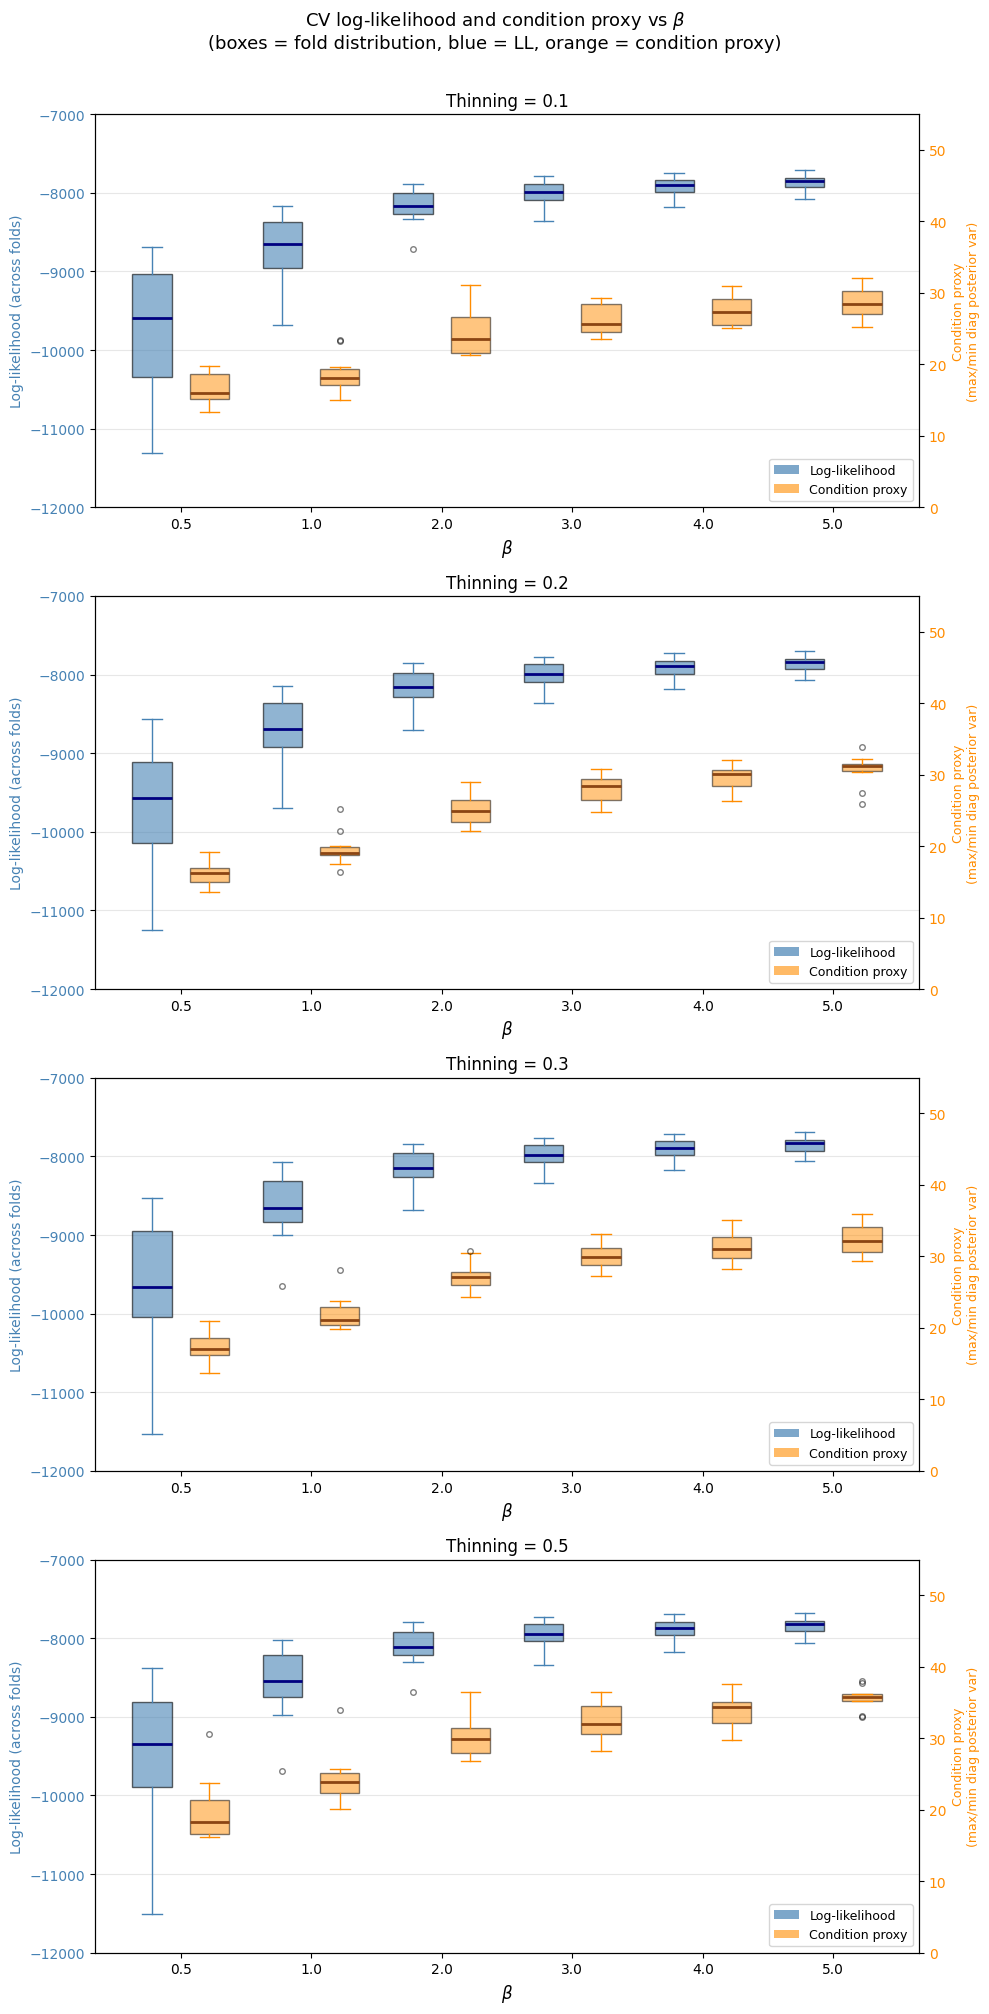

In [81]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(
    len(thinning_levels), 1,
    figsize=(10, 5 * len(thinning_levels)),
    sharex=False
)
if len(thinning_levels) == 1:
    axes = [axes]

for ax, thinning in zip(axes, thinning_levels):
    ax2 = ax.twinx()

    ll_by_beta     = {}  # beta → list of LL values across folds
    cond_by_beta   = {}  # beta → list of condition proxy values across folds

    for fold in range(num_folds):
        ll_slice   = ll_betas.sel(fold=fold, thinning=thinning).values
        valid_mask = ~np.isnan(ll_slice)
        betas_valid = np.array(beta_posterior_list)[valid_mask]
        ll_valid    = ll_slice[valid_mask]

        hess_slice  = hessian_inv_diag_betas.sel(fold=fold, thinning=thinning).values
        hess_valid  = hess_slice[valid_mask]   # already negative; ratio still positive
        cond_proxy  = np.nanmax(hess_valid, axis=1) / np.nanmin(hess_valid, axis=1)

        for b, ll_val, cond_val in zip(betas_valid, ll_valid, cond_proxy):
            ll_by_beta.setdefault(b, []).append(ll_val)
            cond_by_beta.setdefault(b, []).append(cond_val)

    betas_sorted = sorted(ll_by_beta.keys())
    n_betas      = len(betas_sorted)
    positions    = np.arange(n_betas)

    # ── spacing so LL and cond boxes don't overlap ──────────────────
    width   = 0.3
    offset  = 0.22

    ll_data   = [ll_by_beta[b]   for b in betas_sorted]
    cond_data = [cond_by_beta[b] for b in betas_sorted]

    # ── LL boxes (left axis) ─────────────────────────────────────────
    bp1 = ax.boxplot(
        ll_data,
        positions=positions - offset,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='navy', linewidth=2),
        whiskerprops=dict(color='steelblue'),
        capprops=dict(color='steelblue'),
        flierprops=dict(marker='o', color='steelblue', markersize=4, alpha=0.5),
        manage_ticks=False
    )

    # ── Condition proxy boxes (right axis) ───────────────────────────
    bp2 = ax2.boxplot(
        cond_data,
        positions=positions + offset,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor='darkorange', alpha=0.5),
        medianprops=dict(color='saddlebrown', linewidth=2),
        whiskerprops=dict(color='darkorange'),
        capprops=dict(color='darkorange'),
        flierprops=dict(marker='o', color='darkorange', markersize=4, alpha=0.5),
        manage_ticks=False
    )

    # ── Axis formatting ──────────────────────────────────────────────
    ax.set_xticks(positions)
    ax.set_xticklabels([str(b) for b in betas_sorted], fontsize=10)
    ax.set_xlabel(r"$\beta$", fontsize=12)
    ax.set_ylabel("Log-likelihood (across folds)", fontsize=10, color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.set_ylim(-12000, -7000)
    ax.set_title(f"Thinning = {thinning}", fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    ax2.set_ylabel("Condition proxy\n(max/min diag posterior var)", 
                   fontsize=9, color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_ylim(0, 55)

    # ── Legend ───────────────────────────────────────────────────────
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue',   alpha=0.7, label='Log-likelihood'),
        Patch(facecolor='darkorange',  alpha=0.6, label='Condition proxy'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

fig.suptitle(
    r"CV log-likelihood and condition proxy vs $\beta$" + "\n"
    "(boxes = fold distribution, blue = LL, orange = condition proxy)",
    fontsize=13, y=1.005
)
plt.savefig("../figs/cv_loglikelihood_condition_proxy_vs_beta.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


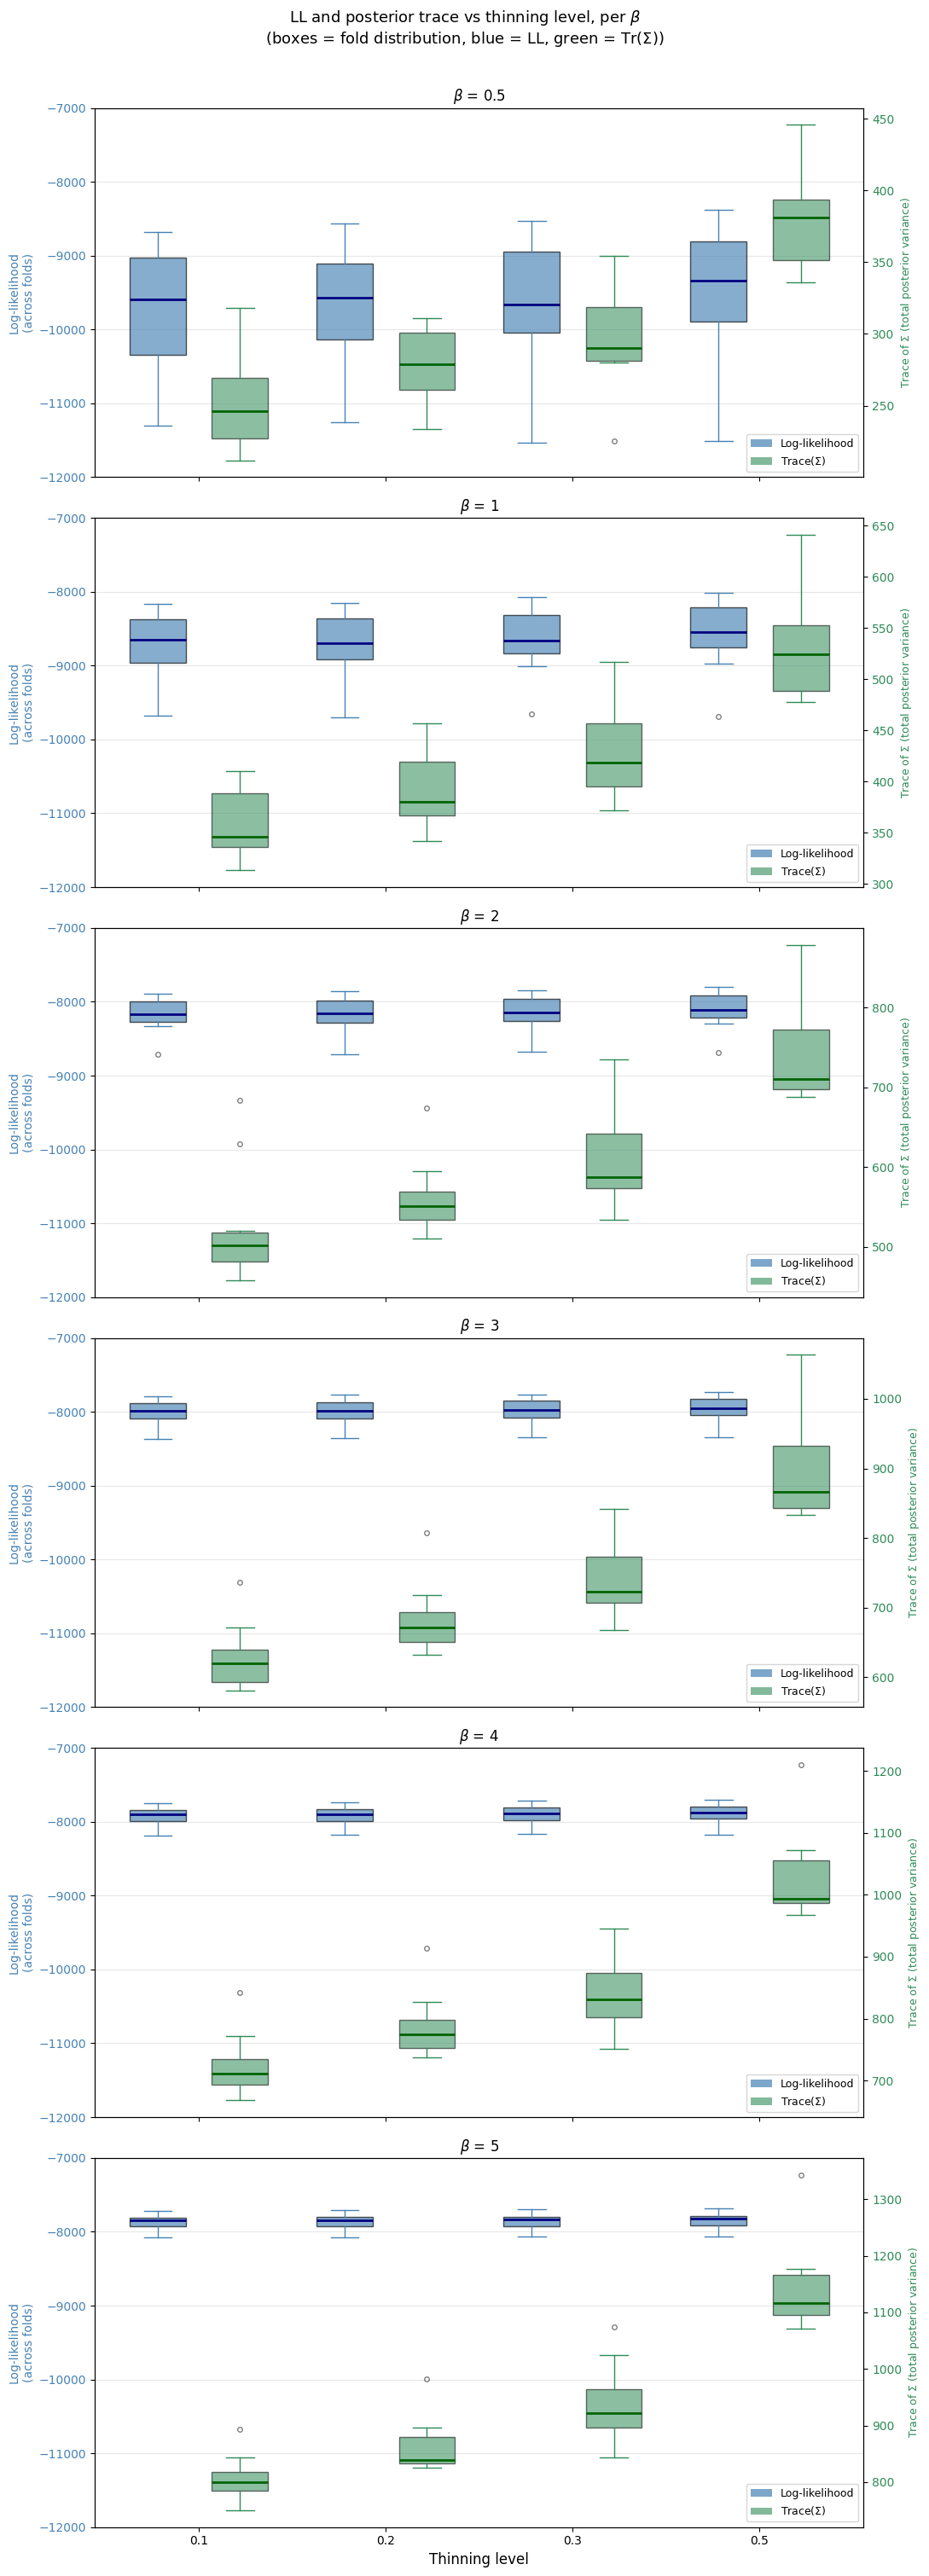

In [84]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.patches import Patch

beta_colors = cm.plasma(np.linspace(0.1, 0.9, len(beta_posterior_list)))

fig, axes = plt.subplots(
    len(beta_posterior_list), 1,
    figsize=(11, 5 * len(beta_posterior_list)),
    sharex=True
)
if len(beta_posterior_list) == 1:
    axes = [axes]

width  = 0.3
offset = 0.22

for ax, beta_val in zip(axes, beta_posterior_list):
    ax2 = ax.twinx()

    ll_by_thinning    = {}
    trace_by_thinning = {}

    beta_idx = list(beta_posterior_list).index(beta_val)

    for fold in range(num_folds):
        for thinning in thinning_levels:

            # ── LL ───────────────────────────────────────────────────
            ll_slice = ll_betas.sel(fold=fold, thinning=thinning).values
            ll_val   = ll_slice[beta_idx]

            if np.isnan(ll_val):
                continue

            ll_by_thinning.setdefault(thinning, []).append(ll_val)

            # ── Trace of posterior covariance ────────────────────────
            hess_slice = hessian_inv_diag_betas.sel(
                fold=fold, thinning=thinning
            ).values                          # (n_betas, n_grid_points)

            hess_row = hess_slice[beta_idx]   # (n_grid_points,)
            if np.all(np.isnan(hess_row)):
                continue

            # diag((-H)^{-1}) gives marginal posterior variances → sum = trace
            trace_val = np.nansum(hess_row)
            trace_by_thinning.setdefault(thinning, []).append(trace_val)

    thinnings_sorted = sorted(ll_by_thinning.keys())
    ll_data          = [ll_by_thinning.get(t, [])    for t in thinnings_sorted]
    trace_data       = [trace_by_thinning.get(t, []) for t in thinnings_sorted]
    pos              = np.arange(len(thinnings_sorted))

    # ── LL boxes (left axis, blue) ───────────────────────────────────
    ax.boxplot(
        ll_data,
        positions=pos - offset,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.65),
        medianprops=dict(color='navy', linewidth=2),
        whiskerprops=dict(color='steelblue'),
        capprops=dict(color='steelblue'),
        flierprops=dict(marker='o', color='steelblue', markersize=4, alpha=0.5),
        manage_ticks=False
    )

    # ── Trace boxes (right axis, green) ─────────────────────────────
    ax2.boxplot(
        trace_data,
        positions=pos + offset,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor='seagreen', alpha=0.55),
        medianprops=dict(color='darkgreen', linewidth=2),
        whiskerprops=dict(color='seagreen'),
        capprops=dict(color='seagreen'),
        flierprops=dict(marker='o', color='seagreen', markersize=4, alpha=0.5),
        manage_ticks=False
    )

    # ── Axis formatting ──────────────────────────────────────────────
    ax.set_xticks(pos)
    ax.set_xticklabels([str(t) for t in thinnings_sorted], fontsize=10)
    ax.set_ylabel("Log-likelihood\n(across folds)", fontsize=10, color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.set_ylim(-12000, -7000)
    ax.set_title(rf"$\beta$ = {beta_val}", fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    ax2.set_ylabel(r"Trace of $\Sigma$ (total posterior variance)",
                   fontsize=9, color='seagreen')
    ax2.tick_params(axis='y', labelcolor='seagreen')

    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Log-likelihood'),
        Patch(facecolor='seagreen',  alpha=0.6, label=r'Trace($\Sigma$)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

axes[-1].set_xlabel("Thinning level", fontsize=12)
fig.suptitle(
    r"LL and posterior trace vs thinning level, per $\beta$" + "\n"
    r"(boxes = fold distribution, blue = LL, green = Tr($\Sigma$))",
    fontsize=13, y=1.005
)
plt.savefig("../figs/cv_loglikelihood_trace_vs_thinning_per_beta.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
